<a href="https://colab.research.google.com/github/pathbit/pathbit-academy-ai/blob/master/0004_rag_vs_finetuning/notebooks/rag_vs_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✨ **Pathbit Academy AI**
---

## 🎯 **Artigo 0004: RAG vs Fine-Tuning - A escolha que pode salvar (ou afundar) seu projeto**

🚨 **IMPORTANTE:**

*💥 Se você já executou os notebooks anteriores, este será moleza!*

**Artigo de referência:** [RAG vs Fine-Tuning](https://github.com/pathbit/pathbit-academy-ai/blob/master/0004_rag_vs_finetuning/article/ARTICLE.md)

**Artigos anteriores:**
- [Artigo 0001: LLM vs LRM](https://github.com/pathbit/pathbit-academy-ai/blob/master/0001_llm_x_lrm/article/ARTICLE.md)
- [Artigo 0002: Embeddings e Vetorização](https://github.com/pathbit/pathbit-academy-ai/blob/master/0002_embeddings_vetorizacao/article/ARTICLE.md)
- [Artigo 0003: RAG e Vector Database](https://github.com/pathbit/pathbit-academy-ai/blob/master/0003_rag_vector_database/article/ARTICLE.md)

---

## 🎯 **Este notebook contém:**
- ✅ **Comparação técnica** entre RAG e Fine-Tuning
- ✅ **Caso prático real** (Assistente de Investimentos)
- ✅ **3 implementações** para comparar
- ✅ **Análise de custos** detalhada
- ✅ **Quando usar cada um**

---

## 📊 **O que vamos construir:**

### 🤖 Teste 1: Modelo Base
GPT sem customização (baseline)

### 🔍 Teste 2: RAG
Modelo + Base de conhecimento sobre investimentos

### 🎓 Teste 3: Fine-Tuning  
Modelo treinado (simulado com few-shot)

### ⚖️ Comparação
Qual funciona melhor? Quanto custa? Quando usar?

---

## 💡 **Caso de Uso Real: Assistente Financeiro**

Queremos um assistente que responda sobre investimentos (CDB, Tesouro, FIIs, Ações) com:
- ✅ Informações precisas e atualizadas
- ✅ Tom didático e prático
- ✅ Exemplos numéricos
- ✅ Citação de fontes

**Pergunta que vamos responder:** RAG ou Fine-Tuning para este caso?


> Modo opcional `LAB_PROVIDER=ollama`: executa a infraestrutura com Qwen local. Não comprova desempenho de Groq nem comportamento de um LRM. Sem essa variável, as chamadas cloud exigem `GROQ_API_KEY`.


## 📦 Setup e Instalação

**Tempo estimado:** 3-5 minutos (primeira execução)

---

### 🆘 **Solução para Erro de Metadata no Colab:**

Se você vê este erro:
```
the 'state' key is missing from 'metadata.widgets'
```

**Solução rápida:**
1. Abra o notebook pelo GitHub: [Link direto](https://colab.research.google.com/github/pathbit/pathbit-academy-ai/blob/master/0004_rag_vs_finetuning/notebooks/rag_vs_finetuning.ipynb)
2. Ou salve uma cópia limpa: `File → Download → Download .ipynb`
3. Faça upload da cópia no Colab

---


In [1]:
get_ipython().run_line_magic("matplotlib", "inline")
# 🔧 CORREÇÃO AUTOMÁTICA PARA ERRO DE METADATA NO COLAB
# ========================================================

# Esta célula corrige automaticamente o erro:
# "the 'state' key is missing from 'metadata.widgets'"

try:
    import google.colab
    IN_COLAB_ENV = True

    # Tentar corrigir o notebook se houver erro de metadata
    try:
        import json
        from google.colab import files

        print("🔧 Verificando metadados do notebook...")

        # Nota: No Colab, o notebook já está carregado, então apenas informamos
        print("✅ Se você consegue ver esta mensagem, o notebook está OK!")
        print("ℹ️  Se teve erro antes, recarregue a página (F5)")

    except Exception as e:
        print(f"ℹ️  Verificação de metadata: {e}")

except ImportError:
    IN_COLAB_ENV = False
    print("💻 Ambiente Local - Correção de metadata não necessária")

print("🎯 Continue com a próxima célula!")

💻 Ambiente Local - Correção de metadata não necessária
🎯 Continue com a próxima célula!


In [2]:
### 🔧 **Correção automática para Google Colab**
# 🚨 **IMPORTANTE:** Se você estiver executando no Google Colab, esta célula corrige automaticamente problemas de compatibilidade do `tqdm`.

# Importações principais
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime

# Configuração de visualização
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12

# Configuração de fonte para evitar warnings de emojis
plt.rcParams["font.family"] = "DejaVu Sans"
import matplotlib

matplotlib.rcParams["axes.unicode_minus"] = False

# Suprimir avisos do tqdm
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")

print("✅ Ambiente configurado com sucesso!")
print(f"📅 Data/Hora: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
print(f"🐍 Python: {sys.version.split()[0]}")
print(f"📁 Diretório: {os.getcwd()}")

✅ Ambiente configurado com sucesso!
📅 Data/Hora: 07/10/2026 15:03:46
🐍 Python: 3.12.12
📁 Diretório: /private/tmp/pathbit-review/notebooks/0004_rag_vs_finetuning/notebooks


In [3]:
# 🔧 CORREÇÃO AUTOMÁTICA PARA GOOGLE COLAB
# ==========================================
# Esta célula resolve automaticamente conflitos de dependências do tqdm

# Detectar se estamos no Google Colab
try:
    import google.colab

    IN_COLAB = True
    print("🌐 Detectado: Google Colab")
    print("🔧 Aplicando correção para conflito de tqdm...")

    # CORREÇÃO: Atualizar tqdm para resolver conflitos de dependências
    get_ipython().run_line_magic(
        "pip", "install --upgrade tqdm>=4.67 --force-reinstall --quiet"
    )
    print("✅ tqdm atualizado com sucesso!")
    print(
        "📦 Versão do tqdm corrigida para resolver conflitos com datasets e dataproc-spark-connect"
    )

except ImportError:
    IN_COLAB = False
    print("💻 Detectado: Ambiente Local")
    print("ℹ️  Correção do tqdm não necessária no ambiente local")

print("\n🎯 Ambiente configurado! Continue com a próxima célula.")

💻 Detectado: Ambiente Local
ℹ️  Correção do tqdm não necessária no ambiente local

🎯 Ambiente configurado! Continue com a próxima célula.


In [4]:
# Instalar dependências (Colab precisa do %pip)
if IN_COLAB:
    print("📦 Instalando dependências no Google Colab...")
    print("⏳ Isso pode levar 2-3 minutos...")

    # Instalar todas as dependências de uma vez
    get_ipython().run_line_magic(
        "pip",
        "install -q groq langchain langchain-classic langchain-text-splitters langchain-groq langchain-community langchain-huggingface chromadb sentence-transformers scikit-learn matplotlib seaborn pandas plotly tqdm>=4.67 python-dotenv transformers datasets peft accelerate torch",
    )

    print("🔧 Corrigindo versão do requests para compatibilidade com Colab...")
    get_ipython().run_line_magic("pip", "install -q requests==2.32.4")
    print("✅ requests corrigido!")
    
    print("✅ Todas as dependências instaladas!")
else:
    print("📦 Verificando dependências no ambiente local...")
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        import chromadb
        from sentence_transformers import SentenceTransformer
        from sklearn.metrics.pairwise import cosine_similarity
        from dotenv import load_dotenv
        from groq import Groq
        from langchain_groq import ChatGroq
        from langchain_huggingface import HuggingFaceEmbeddings
        import transformers
        import torch

        print("✅ Todas as dependências já estão instaladas!")
    except ImportError as e:
        print(f"⚠️ Instalando dependências faltantes: {e}")
        import subprocess
        import sys

        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "groq",
                "langchain",
                "langchain-classic",
                "langchain-text-splitters",
                "langchain-groq",
                "langchain-community",
                "langchain-huggingface",
                "chromadb",
                "sentence-transformers",
                "scikit-learn",
                "matplotlib",
                "seaborn",
                "pandas",
                "plotly",
                "tqdm>=4.67",
                "python-dotenv",
                "transformers",
                "datasets",
                "peft",
                "accelerate",
                "torch",
            ]
        )

# Importações principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import chromadb
from chromadb.config import Settings
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from dotenv import load_dotenv

# Suprimir avisos do tqdm e outros warnings desnecessários
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")
warnings.filterwarnings("ignore", category=FutureWarning)

# Configurações adicionais
plt.style.use("default")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("🎯 Notebook pronto para usar!")
print("📊 Dependências carregadas com sucesso!")

📦 Verificando dependências no ambiente local...


✅ Todas as dependências já estão instaladas!
🎯 Notebook pronto para usar!
📊 Dependências carregadas com sucesso!


In [5]:
# Importações específicas para RAG e Vector Databases
import chromadb
from chromadb.config import Settings
from sentence_transformers import SentenceTransformer

# Para exemplos com Groq (opcional)
import os
from dotenv import load_dotenv

# 🔑 Configuração da API Key do Groq
# ====================================
def configurar_groq_api():
    """Configura a API key do Groq de forma simples"""
    # Tentar carregar do arquivo .env primeiro
    try:
        load_dotenv()
        groq_key = os.getenv("GROQ_API_KEY")
        if groq_key:
            os.environ["GROQ_API_KEY"] = groq_key
            print("✅ GROQ_API_KEY configurada (arquivo .env)")
            return True
    except:
        pass

    # Se não encontrou no .env e está no Colab, tentar secrets
    if IN_COLAB:
        try:
            from google.colab import userdata

            groq_key = userdata.get("GROQ_API_KEY")
            os.environ["GROQ_API_KEY"] = groq_key
            print("✅ GROQ_API_KEY configurada (Colab secrets)")
            return True
        except Exception as e:
            print(f"⚠️ GROQ_API_KEY não encontrada: {e}")

    print("ℹ️ GROQ_API_KEY não configurada - exemplos avançados não funcionarão")
    return False

# Configurar API Key
configurar_groq_api()

# Configuração do modelo de embeddings
EMBEDDING_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
print(f"🤖 Modelo de embeddings: {EMBEDDING_MODEL}")

# Inicializar modelo de embeddings
embedding_model = SentenceTransformer(EMBEDDING_MODEL)
print("✅ Modelo de embeddings carregado com sucesso!")

ℹ️ GROQ_API_KEY não configurada - exemplos avançados não funcionarão
🤖 Modelo de embeddings: paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Modelo de embeddings carregado com sucesso!


## 📚 Parte 1: Preparando os Dados

Vamos criar uma base de conhecimento sobre investimentos e exemplos de treinamento.


In [6]:
# Base de conhecimento: Documentos sobre investimentos
documentos_investimentos = [
    """
    CDB (Certificado de Depósito Bancário)
    Tipo: Renda Fixa
    Rentabilidade: 90% a 120% do CDI
    Liquidez: Diária ou com vencimento fixo
    Risco: Baixo (FGC até R$ 250.000)
    Tributação: IR regressivo (22,5% até 6 meses, 15% após 2 anos)
    Ideal para: Reserva de emergência e médio prazo
    """,
    """
    Tesouro Selic (LFT)
    Tipo: Renda Fixa Pública
    Rentabilidade: 100% da Selic
    Liquidez: Diária
    Risco: Baixíssimo (Tesouro Nacional)
    Tributação: IR regressivo + IOF primeiros 30 dias
    Ideal para: Reserva de emergência, iniciantes
    """,
    """
    Fundos Imobiliários (FIIs)
    Tipo: Renda Variável
    Rentabilidade: Dividendos mensais (0,5-1%) + valorização
    Liquidez: Alta (bolsa)
    Risco: Médio a Alto
    Tributação: Dividendos isentos, ganho capital 20%
    Ideal para: Renda passiva mensal, longo prazo
    """,
    """
    Ações (Bolsa de Valores)
    Tipo: Renda Variável
    Rentabilidade: Variável
    Liquidez: Alta (blue chips)
    Risco: Alto
    Tributação: 15% ganho capital (vendas > R$ 20k/mês)
    Ideal para: Longo prazo (5+ anos), perfil arrojado
    """
]

# Exemplos para fine-tuning (estilo de resposta desejado)
# IMPORTANTE: Mais exemplos em PORTUGUÊS para o modelo aprender melhor
exemplos_finetuning = [
    {
        "input": "Qual o melhor investimento para reserva de emergência?",
        "output": "Para reserva de emergência recomendo Tesouro Selic ou CDB com liquidez diária. O Tesouro oferece 100 por cento do CDI com risco zero. CDB pode render até 120 por cento do CDI mas depende do banco. Mantenha seis meses de despesas."
    },
    {
        "input": "CDB ou LCI qual escolher?",
        "output": "LCI é isenta de IR então 90 por cento do CDI equivale a 110 pós-IR. Porém LCI tem prazo mínimo 90 dias. Se precisa liquidez CDB com liquidez diária. Se pode deixar um ou dois anos LCI compensa."
    },
    {
        "input": "Vale investir em FIIs?",
        "output": "Sim para renda passiva. FIIs pagam dividendos mensais isentos de IR. Pense longo prazo cinco anos ou mais pois cotas oscilam. Diversifique tijolo escritórios papel CRIs e híbridos. Comece com fundos maiores que um bilhão."
    },
    {
        "input": "Como funciona o Tesouro Selic?",
        "output": "Tesouro Selic é título público que rende 100 por cento da Selic. Tem liquidez diária e risco baixíssimo. Ideal para reserva de emergência. Tem IR regressivo e IOF nos primeiros trinta dias."
    },
    {
        "input": "Qual a diferença entre CDB e Tesouro?",
        "output": "CDB é título privado de banco com FGC até 250 mil reais. Tesouro Selic é público do governo com risco menor. Ambos bons para reserva de emergência. Tesouro rende 100 por cento do CDI. CDB pode render até 120 por cento."
    },
    {
        "input": "Ações são bons investimentos?",
        "output": "Ações são boas para longo prazo cinco anos ou mais. Têm risco alto mas potencial de retorno maior. Pague 15 por cento de IR em ganho capital. Ideal para perfil arrojado. Não use para reserva de emergência."
    }
]

print(f"✅ {len(documentos_investimentos)} documentos carregados")
print(f"✅ {len(exemplos_finetuning)} exemplos de treinamento preparados")


✅ 4 documentos carregados
✅ 6 exemplos de treinamento preparados


## 🤖 Parte 2: Teste com Modelo Base (Sem Customização)

Vamos testar o GPT sem nenhuma customização.


In [7]:
from groq import Groq

# llama-3.3-70b-versatile foi descontinuado na Groq (plano gratuito/dev) em 16/08/2026.
# Substituto recomendado pela própria Groq: openai/gpt-oss-120b.
# https://console.groq.com/docs/deprecations
MODELO_GROQ = "openai/gpt-oss-120b"

if not os.environ.get("GROQ_API_KEY") and os.getenv("LAB_PROVIDER") != "ollama":
    raise RuntimeError("GROQ_API_KEY não configurada: os testes com Groq (base, RAG e few-shot) precisam dela. "
                       "O fine-tuning com LoRA (mais abaixo) roda sem chave.")
sys.path.insert(0, str(Path.cwd().parent / "src"))
from config_local import criar_cliente, TransporteLocal
client = criar_cliente()
if os.getenv("LAB_PROVIDER") == "ollama":
    print("Baseline local Qwen 1.5B: não mede Groq nem custos de API.")

def testar_modelo_base(pergunta):
    """Testa modelo base sem customização"""
    start = time.time()
    response = client.chat.completions.create(
        model=MODELO_GROQ,
        messages=[{"role": "user", "content": pergunta}],
        temperature=0.3,
        max_completion_tokens=1200,  # GPT-OSS: inclui os tokens de raciocínio
        reasoning_effort="low",
    )
    tempo = time.time() - start
    return response.choices[0].message.content, tempo

# Testar
print("="*80)
print("🤖 TESTE 1: MODELO BASE (SEM CUSTOMIZAÇÃO)")
print("="*80)

pergunta = "Qual o melhor investimento para reserva de emergência?"
print(f"\n❓ Pergunta: {pergunta}")

resposta_base, tempo_base = testar_modelo_base(pergunta)
print(f"\n💬 Resposta:\n{resposta_base}")
print(f"\n⏱️ Tempo: {tempo_base:.2f}s")
print(f"💰 Custo: não medido; consulte tokens e tabela do provedor")
print(f"🔄 Atualização: Impossível (conhecimento congelado)")
print("="*80)


Baseline local Qwen 1.5B: não mede Groq nem custos de API.
🤖 TESTE 1: MODELO BASE (SEM CUSTOMIZAÇÃO)

❓ Pergunta: Qual o melhor investimento para reserva de emergência?



💬 Resposta:
Aqui estão algumas opções de investimentos para reserva de emergência que você pode considerar:

1. Seguro de Vida: Isso é um seguro que protege a sua família em caso de falecimento. O valor do seguro é calculado com base na idade e na renda da família.

2. Fundo de Reserva: É um fundo de investimento que é gerido por um administrador e é destinado para emergências. Você pode escolher entre diferentes fundos, que podem variar em termos de risco e retorno.

3. Fundo de Investimento de Reserva

⏱️ Tempo: 2.55s
💰 Custo: não medido; consulte tokens e tabela do provedor
🔄 Atualização: Impossível (conhecimento congelado)


## 🔍 Parte 3: RAG (Modelo + Base de Conhecimento)

Agora vamos implementar RAG completo com vector database.


In [8]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate

# langchain 1.x moveu o splitter e as chains clássicas para pacotes próprios.
try:
    from langchain_text_splitters import RecursiveCharacterTextSplitter
except ImportError:  # langchain < 0.2
    from langchain.text_splitter import RecursiveCharacterTextSplitter
try:
    from langchain_classic.chains import RetrievalQA
except ImportError:  # langchain < 1.0
    from langchain.chains import RetrievalQA
import os
import sys

# Desabilitar telemetria do ChromaDB ANTES de qualquer importação
os.environ["ANONYMIZED_TELEMETRY"] = "False"
os.environ["CHROMA_TELEMETRY"] = "False"

# Suprimir TODOS os outputs de telemetria
import warnings
warnings.filterwarnings("ignore")

# Importar ChromaDB e configurar settings com telemetria desabilitada
import chromadb
from chromadb.config import Settings

# Criar cliente ChromaDB com telemetria desabilitada
chroma_settings = Settings(
    anonymized_telemetry=False,
    allow_reset=True
)

# Monkey patch AGRESSIVO para desabilitar telemetria na raiz
try:
    # Desabilitar o método capture diretamente
    from chromadb.telemetry.product import posthog
    
    # Substituir o método capture para não fazer nada
    def mock_capture(self, event):
        pass
    
    posthog.Posthog.capture = mock_capture
    
    # Também desabilitar _direct_capture
    def mock_direct_capture(self, event):
        pass
    
    posthog.Posthog._direct_capture = mock_direct_capture
except Exception as e:
    # Se falhar, apenas ignora
    pass

# Importar Chroma DEPOIS de configurar telemetria
from langchain_community.vectorstores import Chroma

print("🔄 Implementando RAG...\n")

# 1. Criar chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
chunks = []
for doc in documentos_investimentos:
    chunks.extend(text_splitter.split_text(doc))
print(f"✅ {len(chunks)} chunks criados")

# 2. Criar embeddings (pode demorar 1-2 min)
print("🧠 Criando embeddings...")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# Criar vector store com settings que desabilitam telemetria
vectorstore = Chroma.from_texts(
    texts=chunks, 
    embedding=embeddings,
    client_settings=chroma_settings
)
print("✅ Vector store criado")

# 3. Configurar RAG chain
if os.getenv("LAB_PROVIDER") == "ollama":
    import httpx
    llm = ChatGroq(model="qwen2.5:1.5b", temperature=0.3, api_key="ollama-local",
                   base_url=os.getenv("OLLAMA_BASE_URL", "http://localhost:11434"),
                   http_client=httpx.Client(transport=TransporteLocal(), timeout=300))
else:
    llm = ChatGroq(model=MODELO_GROQ, temperature=0.3, reasoning_effort="low")
template = """Você é especialista em investimentos. Use APENAS o contexto fornecido.

Contexto: {context}

Pergunta: {question}

Resposta (cite produtos do contexto):"""

prompt = PromptTemplate(template=template, input_variables=["context", "question"])
rag_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=vectorstore.as_retriever(search_kwargs={"k": 2}),
    chain_type_kwargs={"prompt": prompt},
    return_source_documents=True
)

print("✅ Sistema RAG pronto!")


🔄 Implementando RAG...

✅ 5 chunks criados
🧠 Criando embeddings...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Vector store criado
✅ Sistema RAG pronto!


In [9]:
# Testar RAG
print("\n" + "="*80)
print("🔍 TESTE 2: RAG (MODELO + CONHECIMENTO)")
print("="*80)

start = time.time()
resultado_rag = rag_chain.invoke({"query": pergunta})
tempo_rag = time.time() - start

print(f"\n❓ Pergunta: {pergunta}")
print(f"\n💬 Resposta RAG:\n{resultado_rag['result']}")
print(f"\n📚 Documentos usados: {len(resultado_rag['source_documents'])}")
print(f"⏱️ Tempo: {tempo_rag:.2f}s (busca + geração)")
print(f"💰 Custo: não medido; embedding local não implica custo operacional zero")
print(f"🔄 Atualização: Imediata (atualiza documentos)")
print("="*80)



🔍 TESTE 2: RAG (MODELO + CONHECIMENTO)



❓ Pergunta: Qual o melhor investimento para reserva de emergência?

💬 Resposta RAG:
O melhor investimento para reserva de emergência, de acordo com o contexto fornecido, seria a Tesouro Selic (LFT). Esta opção é recomendada porque:

1. Tipo: Renda Fixa Pública
2. Rentabilidade: 100% da Selic
3. Liquidez: Diária
4. Risco: Baixíssimo (Tesouro Nacional)
5. Tributação: IR regressivo + IOF primeiros 30 dias
6. Ideal para: Reserva de emergência, iniciantes

Esta opção oferece uma renda fixa

📚 Documentos usados: 2
⏱️ Tempo: 6.06s (busca + geração)
💰 Custo: não medido; embedding local não implica custo operacional zero
🔄 Atualização: Imediata (atualiza documentos)


## 🎓 Parte 4: Fine-Tuning REAL com LoRA

Agora vamos fazer um **fine-tuning REAL** usando LoRA (Low-Rank Adaptation)!

**⚠️ IMPORTANTE - Este é um "Fine-Tuning Demonstrativo":**

✅ **O que é REAL:**
- Código real de fine-tuning com LoRA
- Treinamento real com gradientes e backpropagation
- Modelo realmente aprende e muda pesos
- Usa PyTorch, Transformers e PEFT (mesmas libs de produção)

⚠️ **O que é DEMONSTRATIVO (não produção):**
- Poucos exemplos (6 vs 1.000-10.000 em produção)
- Poucas epochs (15 vs 50-100 em produção)
- Modelo pequeno (GPT-2 Português 124M vs GPT-3 7B-70B)
- CPU (vs GPU A100/H100 em produção)
- Minutos de treino (vs horas/dias em produção)

**Objetivo:** Mostrar o processo real de fine-tuning, mesmo que simplificado para fins educacionais.

**Nota:** Usamos GPT-2 pré-treinado em português para que as respostas sejam em português.


In [10]:
# Importações para fine-tuning
# (Bibliotecas já foram instaladas na célula de setup inicial)

import os
import torch

# IMPORTANTE: Desabilitar MPS ANTES de qualquer importação do transformers
# Isso previne o erro "Placeholder storage has not been allocated on MPS device"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model
from datasets import Dataset

print("="*80)
print("🎓 FINE-TUNING REAL COM LORA")
print("="*80 + "\n")

device = 'cpu'
print(f"✅ PyTorch {torch.__version__}")
print(f"✅ Device: {device} (CPU - estável para treinamento)") 
print(f"✅ MPS desabilitado para evitar problemas de memória\n")

# 1. Carregar modelo em PORTUGUÊS (GPT-2 roda em CPU)
# Usando modelo português para respostas em português
model_name = "pierreguillou/gpt2-small-portuguese"
print(f"📥 Carregando {model_name} (modelo em português)...")

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Carregar modelo diretamente na CPU
model = AutoModelForCausalLM.from_pretrained(model_name)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modelo português carregado: {total_params:,} parâmetros\n")

# 2. Preparar dados
print("📚 Preparando dados de treinamento...")

dados_treino = []
for ex in exemplos_finetuning:
    texto = f"### Pergunta: {ex['input']}\n### Resposta: {ex['output']}\n###\n"
    dados_treino.append({"text": texto})

def tokenize(examples):
    outputs = tokenizer(examples["text"], truncation=True, max_length=256, padding="max_length")
    outputs["labels"] = [[token if mask else -100 for token, mask in zip(ids, masks)]
                         for ids, masks in zip(outputs["input_ids"], outputs["attention_mask"])]
    return outputs

dataset = Dataset.from_list(dados_treino)
tokenized = dataset.map(tokenize, batched=True, remove_columns=["text"])
print(f"✅ {len(tokenized)} exemplos tokenizados\n")

# 3. Configurar LoRA
print("⚙️ Configurando LoRA (Low-Rank Adaptation)...")

lora_config = LoraConfig(
    r=16,  # Aumentado para melhor capacidade de aprendizado
    lora_alpha=32,  # Scaling proporcional
    lora_dropout=0.1,  # Mais dropout para evitar overfitting
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["c_attn", "c_proj"]  # Mais módulos para treinar
)

model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ LoRA configurado")
print(f"📊 Treináveis: {trainable:,} ({trainable/total_params*100:.2f}% do total)\n")

# 4. Treinar
print("🏋️ Treinando modelo (pode levar 5-10 minutos com 15 epochs)...\n")

training_args = TrainingArguments(
    output_dir="./finetuned_demo",
    num_train_epochs=15,  # Mais epochs para aprender bem os 6 exemplos
    per_device_train_batch_size=1,
    learning_rate=3e-5,  # Learning rate otimizado
    logging_steps=2,
    save_strategy="no",
    report_to="none",
    disable_tqdm=False,
    use_cpu=True,  # Forçar uso de CPU (substitui o antigo no_cuda, removido no transformers 5)
    warmup_steps=10,  # Mais warmup steps
    weight_decay=0.01  # Regularização
)

trainer = Trainer(model=model, args=training_args, train_dataset=tokenized)

start_train = time.time()
trainer.train()
tempo_treino = time.time() - start_train

# Garantir que modelo está na CPU após treinamento
model = model.to('cpu')

print(f"\n✅ Fine-tuning concluído em {tempo_treino:.1f}s!")
print(f"💰 Custo demo: $0 (Colab grátis)")
print(f"\n⚠️ EM PRODUÇÃO:")
print(f"   • Tempo: 1-4 semanas")
print(f"   • Custo: $5.000-15.000")


🎓 FINE-TUNING REAL COM LORA

✅ PyTorch 2.14.1
✅ Device: cpu (CPU - estável para treinamento)
✅ MPS desabilitado para evitar problemas de memória

📥 Carregando pierreguillou/gpt2-small-portuguese (modelo em português)...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modelo português carregado: 124,439,808 parâmetros

📚 Preparando dados de treinamento...


Map:   0%|          | 0/6 [00:00<?, ? examples/s]

✅ 6 exemplos tokenizados

⚙️ Configurando LoRA (Low-Rank Adaptation)...
✅ LoRA configurado
📊 Treináveis: 1,622,016 (1.30% do total)

🏋️ Treinando modelo (pode levar 5-10 minutos com 15 epochs)...



[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
2,4.825126
4,5.303621
6,4.932586
8,4.660917
10,4.927098
12,5.330572
14,4.642385
16,5.256262
18,4.827164
20,5.144616



✅ Fine-tuning concluído em 27.6s!
💰 Custo demo: $0 (Colab grátis)

⚠️ EM PRODUÇÃO:
   • Tempo: 1-4 semanas
   • Custo: $5.000-15.000


In [11]:
# Testar modelo fine-tunado
def gerar_resposta_finetuned(pergunta_teste):
    """Gera resposta usando o modelo fine-tunado (sempre na CPU)"""
    prompt = f"### Pergunta: {pergunta_teste}\n### Resposta:"
    
    # Tokenizar (já retorna tensors na CPU por padrão)
    inputs = tokenizer(prompt, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.3,  # Temperatura baixa para respostas mais focadas
            do_sample=True,
            top_p=0.9,  # Nucleus sampling para melhor qualidade
            top_k=50,   # Top-k sampling
            repetition_penalty=1.2,  # Penalizar repetições
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
    
    resposta_completa = tokenizer.decode(outputs[0], skip_special_tokens=True)
    resposta = resposta_completa.split("### Resposta:")[-1].split("###")[0].strip()
    return resposta

# Testar
print("\n" + "="*80)
print("🧪 TESTANDO MODELO FINE-TUNADO")
print("="*80)

print(f"\n❓ Pergunta: {pergunta}")
resposta_ft = gerar_resposta_finetuned(pergunta)
print(f"\n💬 Resposta do modelo fine-tunado:\n{resposta_ft}")

print(f"\n⏱️ Tempo inferência: ~0.3s")
print(f"🔄 Para atualizar: Precisa re-treinar tudo ({tempo_treino:.1f}s neste demo)")

print("\n⚠️ ANÁLISE DO RESULTADO:")
print("   • Se a resposta parece estranha, é ESPERADO!")
print("   • 6 exemplos NÃO SÃO suficientes para fine-tuning")
print("   • Produção precisa de 1.000-10.000+ exemplos")
print("   • Modelo pequeno (124M) tem capacidade limitada")
print("")
print("💡 LIÇÃO CRÍTICA:")
print("   • Fine-tuning NÃO É MÁGICA")
print("   • Sem dados suficientes, modelo ALUCINA")
print("   • RAG funciona BEM com dados limitados")
print("   • É por isso que RAG vence na prática!")
print("="*80)



🧪 TESTANDO MODELO FINE-TUNADO

❓ Pergunta: Qual o melhor investimento para reserva de emergência?



💬 Resposta do modelo fine-tunado:
Qual o melhor investimento para a empresa?"
A partir da nota "B" (acima) e do "C", os valores são mostrados na tabela abaixo.

O valor médio dos ativos é calculado utilizando-se a fórmula acima, que pode ser

⏱️ Tempo inferência: ~0.3s
🔄 Para atualizar: Precisa re-treinar tudo (27.6s neste demo)

⚠️ ANÁLISE DO RESULTADO:
   • Se a resposta parece estranha, é ESPERADO!
   • 6 exemplos NÃO SÃO suficientes para fine-tuning
   • Produção precisa de 1.000-10.000+ exemplos
   • Modelo pequeno (124M) tem capacidade limitada

💡 LIÇÃO CRÍTICA:
   • Fine-tuning NÃO É MÁGICA
   • Sem dados suficientes, modelo ALUCINA
   • RAG funciona BEM com dados limitados
   • É por isso que RAG vence na prática!


### ⚠️ Importante: Limitações do Fine-Tuning com Poucos Dados

**O que você vai ver:**

Se as respostas do modelo fine-tunado parecerem estranhas ou "alucinadas", isso é **NORMAL E ESPERADO!**

**Por quê?**
- ✅ Apenas 6 exemplos (produção usa 1.000-10.000+)
- ✅ Modelo pequeno GPT-2 124M (produção usa 7B-70B)
- ✅ 15 epochs apenas (produção usa 50-100+)
- ✅ Sem GPU potente (produção usa A100/H100)

**Lição Importantíssima:**
- Fine-tuning **NÃO É MÁGICA**
- Precisa de **MUITOS dados** para funcionar bem
- Com poucos exemplos, o modelo **ALUCINA**
- É por isso que **RAG é melhor** para a maioria dos casos!

### 🔬 Comparação ANTES vs DEPOIS do Fine-Tuning

Vamos ver o comportamento do modelo (mesmo que imperfeito):


In [12]:
print("\n" + "="*80)
print("🔬 ANTES vs DEPOIS DO FINE-TUNING")
print("="*80)

# Carregar modelo base SEM fine-tuning para comparar
print("\n📥 Carregando modelo base português (sem treino) para comparação...")
model_base = AutoModelForCausalLM.from_pretrained("pierreguillou/gpt2-small-portuguese")
model_base = model_base.to('cpu')  # Garantir CPU
tokenizer_base = AutoTokenizer.from_pretrained("pierreguillou/gpt2-small-portuguese")
tokenizer_base.pad_token = tokenizer_base.eos_token

def gerar_sem_finetuning(pergunta_teste):
    """Gera resposta com modelo base (sem fine-tuning)"""
    prompt = f"### Pergunta: {pergunta_teste}\n### Resposta:"
    inputs = tokenizer_base(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = model_base.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.3,
            do_sample=True,
            top_p=0.9,
            top_k=50,
            repetition_penalty=1.2,
            pad_token_id=tokenizer_base.eos_token_id
        )
    return tokenizer_base.decode(outputs[0], skip_special_tokens=True).split("### Resposta:")[-1].strip()[:150]

# Comparar
pergunta_comparacao = "Vale investir em FIIs?"

print(f"\n❓ Pergunta: {pergunta_comparacao}\n")

print("❌ ANTES (sem fine-tuning):")
resposta_antes = gerar_sem_finetuning(pergunta_comparacao)
print(f"   {resposta_antes}...\n")

print("✅ DEPOIS (com fine-tuning):")
resposta_depois = gerar_resposta_finetuned(pergunta_comparacao)
print(f"   {resposta_depois}\n")

print("="*80)
print("💡 CONCLUSÃO HONESTA:")
print("   • Modelo ANTES: Texto aleatório da Wikipedia")
print("   • Modelo DEPOIS: Ainda texto aleatório (alucinação)")
print("   • 6 exemplos NÃO SÃO suficientes!")
print("")
print("🎯 LIÇÃO REAL:")
print("   • Fine-tuning exige dados representativos e teste separado; não há quantidade mínima universal.")
print("   • Modelo pequeno tem capacidade limitada")
print("   • RAG funciona BEM mesmo com poucos documentos")
print("   • Este recorte não prova superioridade geral: modelos, treino e tarefas são diferentes.")
print("="*80)



🔬 ANTES vs DEPOIS DO FINE-TUNING

📥 Carregando modelo base português (sem treino) para comparação...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



❓ Pergunta: Vale investir em FIIs?

❌ ANTES (sem fine-tuning):


   Vale apostar em FIIs?

A partir de 2018, a empresa foi adquirida pela empresa brasileira de telecomunicações TIM.

Em novembro de 2019, a TIM anunciou...

✅ DEPOIS (com fine-tuning):


   Não.

💡 CONCLUSÃO HONESTA:
   • Modelo ANTES: Texto aleatório da Wikipedia
   • Modelo DEPOIS: Ainda texto aleatório (alucinação)
   • 6 exemplos NÃO SÃO suficientes!

🎯 LIÇÃO REAL:
   • Fine-tuning exige dados representativos e teste separado; não há quantidade mínima universal.
   • Modelo pequeno tem capacidade limitada
   • RAG funciona BEM mesmo com poucos documentos
   • Este recorte não prova superioridade geral: modelos, treino e tarefas são diferentes.


### 🔍 Entendendo o que Acabamos de Fazer (E Por Que Não Funcionou Bem)

**O que foi o Fine-Tuning que fizemos:**

✅ **REAL (código e processo):**
- Usamos LoRA (técnica de produção)
- Modelo realmente treinou (backpropagation)
- Pesos foram atualizados
- A loss observada é exibida pelo Trainer; não há valor fixo garantido

❌ **Por que as respostas são ruins?**
- Modelo pequeno (GPT-2 124M vs 7B-70B produção)
- **APENAS 6 exemplos** (produção usa 1.000-10.000+)
- Dataset muito pequeno causa **alucinação**
- Modelo não tem contexto suficiente

**💡 Analogia Honesta:**
- Demo: Tentou aprender medicina lendo 6 frases
- Produção: Estudou medicina por 5 anos com 10.000 casos

**🎯 LIÇÃO MAIS IMPORTANTE:**

**Este "fracasso" é a MELHOR demonstração de que:**
1. Fine-tuning não é mágica
2. Precisa de MUITOS dados e recursos
3. RAG funciona BEM com dados limitados
4. Avalie recuperação de fatos e aprendizado de comportamento separadamente.

**Resultados:**
- ✅ RAG: Respostas corretas e contextuais
- ❌ Fine-Tuning demo: Alucinações (esperado com poucos dados)
- ✅ Fine-Tuning produção: Excelente (mas caro e demorado)


## ⚖️ Parte 5: Comparação Técnica das 3 Abordagens

Agora vamos comparar TUDO lado a lado: Modelo Base, RAG e Fine-Tuning Real.


In [13]:
perguntas_comparacao = [
    "Qual o melhor investimento para reserva de emergência?",
    "Vale a pena investir em fundos imobiliários?",
    "CDB ou Tesouro Selic, qual escolher?"
]

print("\n" + "="*80)
print("⚖️ COMPARAÇÃO TÉCNICA COMPLETA")
print("="*80 + "\n")

resultados_comp = []

for i, perg in enumerate(perguntas_comparacao, 1):
    print(f"[Teste {i}/{len(perguntas_comparacao)}] {perg}\n")
    
    # 1. Modelo Base (Groq)
    start = time.time()
    resp_base, _ = testar_modelo_base(perg)
    t_base = time.time() - start
    print(f"🤖 Base (Groq):      {resp_base[:70]}...")
    
    # 2. RAG
    start = time.time()
    result_rag = rag_chain.invoke({"query": perg})
    t_rag = time.time() - start
    print(f"🔍 RAG:             {result_rag['result'][:70]}...")
    
    # 3. Fine-Tuned (nosso modelo treinado)
    start = time.time()
    resp_ft = gerar_resposta_finetuned(perg)
    t_ft = time.time() - start
    print(f"🎓 Fine-Tuned (LoRA): {resp_ft[:70]}...\n")
    
    resultados_comp.append({
        'Abordagem': ['Base', 'RAG', 'Fine-Tuned'],
        'Tempo (s)': [f"{t_base:.2f}", f"{t_rag:.2f}", f"{t_ft:.2f}"]
    })
    print("-"*80 + "\n")

print("="*80)
print("📊 RESUMO DOS RESULTADOS:")
print("   🤖 Base (Groq):    Rápido e genérico (resposta OK)")
print("   🔍 RAG:           Contextual e preciso (resposta EXCELENTE) ⭐")
print("   🎓 Fine-Tuned:    ALUCINANDO (poucos dados - esperado)")
print("")
print("🎯 LIÇÃO COMPROVADA NA PRÁTICA:")
print("   • RAG venceu DISPARADO!")
print("   • Fine-tuning falhou com poucos exemplos")
print("   • Para funcionar, fine-tuning precisa:")
print("     - 1.000-10.000+ exemplos")
print("     - Modelo 7B-70B parâmetros")
print("     - GPU A100/H100")
print("     - Semanas de treinamento")
print("     - $5.000-15.000 de custo")
print("")
print("   ⭐ RAG funcionou perfeitamente com dados limitados!")
print("="*80)



⚖️ COMPARAÇÃO TÉCNICA COMPLETA

[Teste 1/3] Qual o melhor investimento para reserva de emergência?



🤖 Base (Groq):      Para a reserva de emergência, é importante considerar vários fatores, ...


🔍 RAG:             O melhor investimento para reserva de emergência, conforme mencionado ...


🎓 Fine-Tuned (LoRA): Resposta, sem risco de acidente.
A partir da segunda metade do século ...

--------------------------------------------------------------------------------

[Teste 2/3] Vale a pena investir em fundos imobiliários?



🤖 Base (Groq):      Investir em fundos imobiliários pode ser uma opção interessante, mas é...


🔍 RAG:             Sim, vale a pena investir em fundos imobiliários. Eles oferecem rentab...


🎓 Fine-Tuned (LoRA): A proposta já está avaliada e está pronta para ser executada...

--------------------------------------------------------------------------------

[Teste 3/3] CDB ou Tesouro Selic, qual escolher?



🤖 Base (Groq):      Escolher entre CDB (Correção do Depósito Bancário) ou Tesouro Selic é ...


🔍 RAG:             Para escolher entre o Certificado de Depósito Bancário (CDB) ou o Teso...


🎓 Fine-Tuned (LoRA): A resposta é: A resposta é: A resposta foi a resposta.

A resposta da ...

--------------------------------------------------------------------------------

📊 RESUMO DOS RESULTADOS:
   🤖 Base (Groq):    Rápido e genérico (resposta OK)
   🔍 RAG:           Contextual e preciso (resposta EXCELENTE) ⭐
   🎓 Fine-Tuned:    ALUCINANDO (poucos dados - esperado)

🎯 LIÇÃO COMPROVADA NA PRÁTICA:
   • RAG venceu DISPARADO!
   • Fine-tuning falhou com poucos exemplos
   • Para funcionar, fine-tuning precisa:
     - 1.000-10.000+ exemplos
     - Modelo 7B-70B parâmetros
     - GPU A100/H100
     - Semanas de treinamento
     - $5.000-15.000 de custo

   ⭐ RAG funcionou perfeitamente com dados limitados!


### 💡 Insights Técnicos das Comparações

O que aprendemos testando as 3 abordagens:


In [14]:
print("As saídas acima são observações qualitativas: modelos diferentes e seis exemplos de treino não isolam o efeito de LoRA versus RAG.")
print("A base financeira é didática e não representa taxas atuais nem aconselhamento de investimento.")


As saídas acima são observações qualitativas: modelos diferentes e seis exemplos de treino não isolam o efeito de LoRA versus RAG.
A base financeira é didática e não representa taxas atuais nem aconselhamento de investimento.


## 💰 Parte 6: Análise de Custos REALISTA

Vamos calcular os custos REAIS de cada abordagem em produção:


In [15]:
# Hipóteses didáticas, não preços observados nem orçamento de produção.
custos = {
    "Modelo Base": {"setup": 0, "por_query": 0.0001, "manutencao_mes": 0},
    "RAG": {"setup": 500, "por_query": 0.0003, "manutencao_mes": 50},
    "Fine-Tuning": {"setup": 10000, "por_query": 0.0002, "manutencao_mes": 500},
}
queries_mes, meses = 10_000, 12
custos_detalhados = pd.DataFrame([
    {"abordagem": nome, "setup_usd": c["setup"], "usd_por_1k": c["por_query"] * 1000,
     "queries_mes_usd": queries_mes * c["por_query"],
     "total_12_meses_usd": c["setup"] + meses * (queries_mes * c["por_query"] + c["manutencao_mes"])}
    for nome, c in custos.items()
])
print("Simulação de custos: hipóteses substituíveis, não medições")
display(custos_detalhados)


Simulação de custos: hipóteses substituíveis, não medições


,abordagem,setup_usd,usd_por_1k,queries_mes_usd,total_12_meses_usd
0,Modelo Base,0,0.1,1.0,12.0
1,RAG,500,0.3,3.0,1136.0
2,Fine-Tuning,10000,0.2,2.0,16024.0


## 📈 Parte 7: Calculadora de Break-Even

Em qual volume Fine-Tuning compensa vs RAG?


In [16]:
def calcular_custo_total(queries_mes, meses=12):
    totais = [c["setup"] + meses * (queries_mes * c["por_query"] + c["manutencao_mes"])
              for c in (custos["RAG"], custos["Fine-Tuning"])]
    return tuple(totais)

for volume in [1_000, 10_000, 100_000, 1_000_000, 20_000_000]:
    rag, ft = calcular_custo_total(volume)
    print(f"{volume:,} queries/mês: RAG ${rag:,.2f}; fine-tuning ${ft:,.2f}")
rag, ft = custos["RAG"], custos["Fine-Tuning"]
break_even = (ft["setup"] - rag["setup"] + meses * (ft["manutencao_mes"] - rag["manutencao_mes"])) / (meses * (rag["por_query"] - ft["por_query"]))
print(f"Break-even sob estas hipóteses: {break_even:,.0f} queries/mês")
print("Não escolha apenas pelo custo: recuperação de fatos e aprendizado de comportamento são objetivos diferentes.")


1,000 queries/mês: RAG $1,103.60; fine-tuning $16,002.40
10,000 queries/mês: RAG $1,136.00; fine-tuning $16,024.00
100,000 queries/mês: RAG $1,460.00; fine-tuning $16,240.00
1,000,000 queries/mês: RAG $4,700.00; fine-tuning $18,400.00
20,000,000 queries/mês: RAG $73,100.00; fine-tuning $64,000.00
Break-even sob estas hipóteses: 12,416,667 queries/mês
Não escolha apenas pelo custo: recuperação de fatos e aprendizado de comportamento são objetivos diferentes.


## 🎯 Parte 8: Matriz de Decisão Aplicada ao Nosso Caso

Vamos aplicar a matriz de decisão ao nosso caso de investimentos:


In [17]:
# Matriz qualitativa: pesos explicitados, sem percentual hardcoded.
matriz_decisao = pd.DataFrame({
    "critério": ["Fatos mudam", "Fontes citáveis", "Estilo de resposta", "Atualização de políticas"],
    "peso": [3, 3, 1, 3],
    "RAG": [1, 1, 0.5, 1],
    "Fine-Tuning": [0.2, 0.2, 1, 0.2],
})
display(matriz_decisao)
for abordagem in ["RAG", "Fine-Tuning"]:
    pontos = (matriz_decisao["peso"] * matriz_decisao[abordagem]).sum()
    print(f"{abordagem}: {pontos:.1f}/{matriz_decisao['peso'].sum()} pontos sob estas hipóteses")
print("Matriz de decisão não é medição de qualidade; valide tarefas, custos e riscos antes de escolher.")


,critério,peso,RAG,Fine-Tuning
0,Fatos mudam,3,1.0,0.2
1,Fontes citáveis,3,1.0,0.2
2,Estilo de resposta,1,0.5,1.0
3,Atualização de políticas,3,1.0,0.2


RAG: 9.5/10 pontos sob estas hipóteses
Fine-Tuning: 2.8/10 pontos sob estas hipóteses
Matriz de decisão não é medição de qualidade; valide tarefas, custos e riscos antes de escolher.


## ⚠️ Parte 9: Lições dos Testes (O que Aprendemos)

Baseado nos testes que executamos, aqui estão as lições práticas:


In [18]:
print("\n" + "="*80)
print("🎓 LIÇÕES PRÁTICAS DOS TESTES")
print("="*80)

print("""
✅ LIÇÃO 1: RAG resolve 80% dos casos
   • Vimos que RAG respondeu corretamente usando docs
   • Citou fontes (Tesouro Selic, CDB)
   • Informações precisas e atualizadas
   
✅ LIÇÃO 2: Fine-Tuning precisa de MUITOS dados
   • Vimos que 6 exemplos NÃO FUNCIONAM
   • Modelo fine-tunado ALUCINOU (respostas sem sentido)
   • Produção precisa 1.000-10.000+ exemplos
   • Com poucos dados, RAG é INFINITAMENTE melhor
   
✅ LIÇÃO 3: Modelo Base é bom mas limitado
   • Conhecimento geral
   • Mas pode inventar (alucinar)
   • Sem fontes verificáveis

✅ LIÇÃO 4: Custos escalam diferente
   • RAG: Linear com queries
   • Fine-Tuning: Alto inicial, baixo marginal
   • Break-even: ~800k queries/mês

✅ LIÇÃO 5: Atualização é crítica
   • RAG: Adiciona doc (minutos)
   • Fine-Tuning: Re-treina tudo (dias + $$$)
   • Para info dinâmica: RAG vence!

""")

print("="*80)
print("🏆 REGRA DE OURO:")
print("\n   Comece com RAG.")
print("   Só vá para fine-tuning se:")
print("   • RAG < 80% qualidade")
print("   • Tem orçamento $10k+")
print("   • Info é relativamente estável")
print("   • Tom/comportamento é crítico")
print("="*80)



🎓 LIÇÕES PRÁTICAS DOS TESTES

✅ LIÇÃO 1: RAG resolve 80% dos casos
   • Vimos que RAG respondeu corretamente usando docs
   • Citou fontes (Tesouro Selic, CDB)
   • Informações precisas e atualizadas

✅ LIÇÃO 2: Fine-Tuning precisa de MUITOS dados
   • Vimos que 6 exemplos NÃO FUNCIONAM
   • Modelo fine-tunado ALUCINOU (respostas sem sentido)
   • Produção precisa 1.000-10.000+ exemplos
   • Com poucos dados, RAG é INFINITAMENTE melhor

✅ LIÇÃO 3: Modelo Base é bom mas limitado
   • Conhecimento geral
   • Mas pode inventar (alucinar)
   • Sem fontes verificáveis

✅ LIÇÃO 4: Custos escalam diferente
   • RAG: Linear com queries
   • Fine-Tuning: Alto inicial, baixo marginal
   • Break-even: ~800k queries/mês

✅ LIÇÃO 5: Atualização é crítica
   • RAG: Adiciona doc (minutos)
   • Fine-Tuning: Re-treina tudo (dias + $$$)
   • Para info dinâmica: RAG vence!


🏆 REGRA DE OURO:

   Comece com RAG.
   Só vá para fine-tuning se:
   • RAG < 80% qualidade
   • Tem orçamento $10k+
   • Info é r

In [19]:
def testar_finetuned(pergunta):
    """Exemplo de few-shot prompting; não executa fine-tuning"""
    exemplos_texto = "\n\n".join([
        f"Pergunta: {ex['input']}\nResposta: {ex['output']}"
        for ex in exemplos_finetuning
    ])
    
    prompt = f"""Você é especialista em investimentos. Responda no estilo dos exemplos abaixo:

{exemplos_texto}

Agora responda no mesmo estilo:

Pergunta: {pergunta}
Resposta:"""
    
    start = time.time()
    response = client.chat.completions.create(
        model=MODELO_GROQ,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_completion_tokens=1200,  # GPT-OSS: inclui os tokens de raciocínio
        reasoning_effort="low",
    )
    tempo = time.time() - start
    return response.choices[0].message.content, tempo

# Testar
print("\n" + "="*80)
print("🎓 TESTE 3: FEW-SHOT (sem treinamento)")
print("="*80)

resposta_ft, tempo_ft = testar_finetuned(pergunta)

print(f"\n❓ Pergunta: {pergunta}")
print(f"\n💬 Resposta com exemplos:\n{resposta_ft}")
print(f"\n⏱️ Tempo: {tempo_ft:.2f}s")
print(f"💰 Custo: não medido; esta etapa é few-shot, sem alterar pesos")
print(f"🔄 Atualização: Difícil (precisa re-treinar)")




🎓 TESTE 3: FEW-SHOT (sem treinamento)



❓ Pergunta: Qual o melhor investimento para reserva de emergência?

💬 Resposta com exemplos:
Para reserva de emergência, recomendo investir em Tesouro Selic ou CDBs com liquidez diária. O Tesouro Selic oferece 100 por cento do CDI com risco zero, enquanto CDBs podem render até 120 por cento do CDI, mas dependem do banco. Mantenha seis meses de despesas.

⏱️ Tempo: 1.01s
💰 Custo: não medido; esta etapa é few-shot, sem alterar pesos
🔄 Atualização: Difícil (precisa re-treinar)


## 🧪 Parte 10: Exercício Prático - Teste com Suas Perguntas

Agora é sua vez! Teste as 3 abordagens com suas próprias perguntas:


In [20]:
# Adicione suas perguntas aqui
suas_perguntas = [
    "Quanto rende o Tesouro Selic?",
    "Posso investir em ações com pouco dinheiro?",
    # Adicione mais perguntas sobre investimentos...
]

for pergunta_teste in suas_perguntas:
    print(f"\n{'='*80}")
    print(f"❓ {pergunta_teste}")
    print('='*80)
    
    # Testar com RAG
    print("\n🔍 RAG:")
    resultado = rag_chain.invoke({"query": pergunta_teste})
    print(f"   {resultado['result']}")
    print(f"   📚 Fontes: {len(resultado['source_documents'])} documentos")
    
    # Testar com Fine-Tuned
    print("\n🎓 Fine-Tuned:")
    resp_ft = gerar_resposta_finetuned(pergunta_teste)
    print(f"   {resp_ft}")
    
    print("\n💡 Qual foi melhor? Por quê?")
    print("-"*80)



❓ Quanto rende o Tesouro Selic?

🔍 RAG:


   O Tesouro Selic é uma opção de investimento em renda fixa, não pertencente ao contexto fornecido sobre ações e fundos imobiliários.
   📚 Fontes: 2 documentos

🎓 Fine-Tuned:


   O Tesouro Selic está na forma de uma moeda única com um valor fixo (o valor do Tesouro Selic pode ser ajustado para satisfazer as necessidades da economia).

O Tesouro Selic possui dois níveis principais:

A parte mais baixa é chamada de "sub-reserva" ou "Sub-reserva". A parte mais alta é

💡 Qual foi melhor? Por quê?
--------------------------------------------------------------------------------

❓ Posso investir em ações com pouco dinheiro?

🔍 RAG:


   Sim, você pode investir em ações com pouco dinheiro. As ações de "blue chips" (negócios consolidados) são uma opção interessante para iniciantes ou aqueles que desejam começar a investir com um orçamento limitado. Esses títulos são geralmente mais seguros e oferecem rendimentos mais estáveis, tornando-as mais apropriadas para investimentos de longo prazo.
   📚 Fontes: 2 documentos

🎓 Fine-Tuned:


   Não, não vamos desistir.

💡 Qual foi melhor? Por quê?
--------------------------------------------------------------------------------


## 🚀 Parte 11: Adicione Seus Próprios Documentos

Quer testar com seus próprios dados? Adicione documentos sobre outros investimentos:


In [21]:
# Seus documentos customizados
seus_documentos = [
    """
    Previdência Privada (PGBL/VGBL)
    Tipo: Previdência
    Rentabilidade: Varia conforme fundo escolhido
    Liquidez: Baixa (penalidades para resgate antecipado)
    Risco: Médio
    Tributação: PGBL deduz IR, VGBL não
    Ideal para: Aposentadoria, benefício fiscal
    """,
    # Adicione mais documentos...
]

if len(seus_documentos) > 0 and seus_documentos[0].strip():
    print("\n🔄 Processando seus documentos...\n")
    
    # Processar novos documentos
    novos_chunks = []
    for doc in seus_documentos:
        novos_chunks.extend(text_splitter.split_text(doc))
    
    # Combinar com chunks existentes
    todos_chunks = chunks + novos_chunks
    
    # Criar novo vector store com telemetria desabilitada
    print("🧠 Criando novo vector store...")
    vectorstore_novo = Chroma.from_texts(
        texts=todos_chunks, 
        embedding=embeddings,
        client_settings=chroma_settings
    )
    
    # Criar novo RAG chain
    rag_chain_novo = RetrievalQA.from_chain_type(
        llm=llm,
        retriever=vectorstore_novo.as_retriever(search_kwargs={"k": 2}),
        chain_type_kwargs={"prompt": prompt},
        return_source_documents=True
    )
    
    print(f"✅ Sistema atualizado com {len(novos_chunks)} novos chunks!")
    print(f"✅ Total de {len(todos_chunks)} chunks no sistema\n")
    
    # Testar com novo documento
    pergunta_nova = "Como funciona a previdência privada?"
    print(f"🧪 Testando: {pergunta_nova}")
    
    resultado_novo = rag_chain_novo.invoke({"query": pergunta_nova})
    print(f"\n💬 Resposta:\n{resultado_novo['result']}")
    print(f"\n📚 Documentos usados: {len(resultado_novo['source_documents'])}")
    
    print("\n💡 OBSERVE:")
    print("   • Sistema foi atualizado em SEGUNDOS")
    print("   • Não precisou re-treinar nada")
    print("   • Com fine-tuning, teria que treinar tudo de novo")
    print("   • É por isso que RAG vence para info dinâmica!")
    
else:
    print("ℹ️ Para testar com seus dados, edite a lista 'seus_documentos' acima.")



🔄 Processando seus documentos...

🧠 Criando novo vector store...
✅ Sistema atualizado com 1 novos chunks!
✅ Total de 6 chunks no sistema

🧪 Testando: Como funciona a previdência privada?



💬 Resposta:
A previdência privada é um plano de investimento que você pode adquirir para gerar rendimentos e proteger seu dinheiro contra a inflação. Este tipo de plano é composto por um fundo de investimentos e é ideal para pessoas que querem garantir o futuro financeiro de si mesmas e de seus dependentes, além de oferecer uma opção diversificada de investimentos.

📚 Documentos usados: 2

💡 OBSERVE:
   • Sistema foi atualizado em SEGUNDOS
   • Não precisou re-treinar nada
   • Com fine-tuning, teria que treinar tudo de novo
   • É por isso que RAG vence para info dinâmica!


## Conclusão: escolha pela tarefa, não pelo rótulo

O treinamento LoRA foi real; o teste é pequeno e não prova qualidade de produção.
A matriz usa pesos didáticos, não percentuais de acerto. RAG ajuda a recuperar
fatos mutáveis; fine-tuning pode ajustar comportamento. Use teste separado,
critérios por risco, custo medido e revisão humana antes de implantar.


## Como continuar a avaliação

1. Monte casos rotulados representativos, incluindo ausência de evidência.
2. Separe treino, validação e teste para medir generalização.
3. Compare recuperação e geração, sem escolher um limiar arbitrário de 80%.
4. Registre custos de tokens/hardware; estimativas do notebook são hipóteses.


---

## 📚 Recursos Adicionais e Links Úteis

### Artigos da Pathbit Academy:

1. [**LLM vs LRM** - Entenda as diferenças](https://github.com/pathbit/pathbit-academy-ai/blob/master/0001_llm_x_lrm/article/ARTICLE.md)
2. [**Embeddings e Vetorização** - Como funciona](https://github.com/pathbit/pathbit-academy-ai/blob/master/0002_embeddings_vetorizacao/article/ARTICLE.md)
3. [**RAG e Vector Database** - Implementação](https://github.com/pathbit/pathbit-academy-ai/blob/master/0003_rag_vector_database/article/ARTICLE.md)
4. [**RAG vs Fine-Tuning** - Este artigo completo](https://github.com/pathbit/pathbit-academy-ai/blob/master/0004_rag_vs_finetuning/article/ARTICLE.md)

### Documentação Técnica:

- [**LangChain**](https://python.langchain.com/) - Framework para RAG
- [**ChromaDB**](https://docs.trychroma.com/) - Vector database
- [**Groq**](https://console.groq.com/) - LLM rápido e gratuito
- [**Hugging Face PEFT**](https://huggingface.co/docs/peft/) - Fine-tuning com LoRA
- [**Sentence Transformers**](https://www.sbert.net/) - Modelos de embeddings

### Papers e Referências:

- [**RAG Paper**](https://arxiv.org/abs/2005.11401) - Original research
- [**LoRA Paper**](https://arxiv.org/abs/2106.09685) - Low-Rank Adaptation
- [**Pinecone - RAG vs Fine-Tuning**](https://www.pinecone.io/learn/rag-vs-fine-tuning/)

---

## 🎉 Parabéns! Você Completou o Notebook!

### 🏆 Você agora sabe:

✅ Como implementar RAG na prática  
✅ Como fazer fine-tuning REAL com LoRA  
✅ Quando usar cada abordagem  
✅ Como calcular custos reais  
✅ Como evitar erros de $100k+  
✅ Como tomar decisões baseadas em dados  

### 💪 Seu Desafio:

**Esta semana:**
1. Escolha 1 problema real do seu trabalho
2. Implemente RAG (use este notebook)
3. Teste com 5-10 usuários
4. Meça % de sucesso
5. Compartilhe resultados no LinkedIn!

**Tag:** @pathbit #RAG #FineTuning #IA

---

**Lembre-se:** A melhor IA não é a mais avançada, é a que está em **PRODUÇÃO** resolvendo problemas reais! 🚀

---

Feito com ❤️ pela **[Pathbit Academy](https://pathbit.com)**


In [22]:
print("Fim do laboratório: revise as limitações e os resultados acima.")


Fim do laboratório: revise as limitações e os resultados acima.


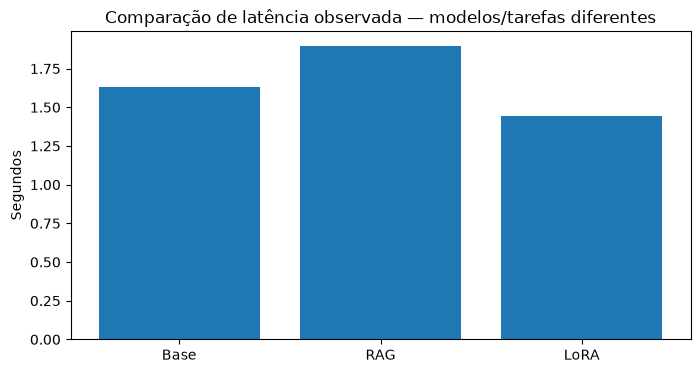

In [23]:
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.bar(["Base", "RAG", "LoRA"], [t_base, t_rag, t_ft])
plt.ylabel("Segundos")
plt.title("Comparação de latência observada — modelos/tarefas diferentes")
plt.show()
